<div style="border-left:6px solid #2a78d6;padding:14px 20px;background:#f4f8fd;border-radius:6px">
<p style="margin:0;color:#52514e;font-size:13px">Data Analytics Básico · Módulo 15 — Análisis avanzado</p>
<h1 style="margin:6px 0 0 0;color:#0b0b0b">15. Regresión y Clasificación Básica</h1>
<p style="margin:8px 0 0 0;color:#52514e">Los dos grandes tipos de problema del aprendizaje supervisado: predecir un <strong>número</strong> (regresión) o una <strong>categoría</strong> (clasificación), con modelos que ya puedes construir y comparar.</p>
</div>

> ### Antes de empezar
>
> En el notebook 14 viste el flujo de modelado. Aquí conoces los **dos tipos de problema** que resuelve el aprendizaje supervisado:
>
> - **Regresión** — predecir un valor continuo (ingresos, demanda, precio).
> - **Clasificación** — predecir una categoría (compra/no compra, churn/no churn).
>
> Construirás un modelo de cada tipo, aprenderás a **medir su calidad** (MAE/RMSE/R² para regresión; accuracy/precision/recall para clasificación) y a **comparar** dos modelos para elegir con criterio. Ejecuta cada celda y observa las métricas.

Cargamos las librerías:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

sns.set_theme(style='ticks')
np.random.seed(42)
pd.set_option('display.max_columns', None)

print('Notebook 15 listo: Regresión y Clasificación Básica')

Notebook 15 listo: Regresión y Clasificación Básica


## Introducción

### ¿Qué es?
Regresión y clasificación son dos enfoques de aprendizaje supervisado.

- En **regresión**, la salida es un valor continuo (por ejemplo, ingresos, demanda, tiempo de entrega).
- En **clasificación**, la salida es una categoría (por ejemplo, compra/no compra, churn/no churn, fraude/no fraude).

Ambos enfoques usan datos históricos etiquetados para aprender patrones y generalizar en datos nuevos.

### ¿Para qué sirve?
Como analista, este bloque te permite pasar de "describir lo que pasó" a "estimar lo que podría pasar".

Aplicaciones directas en negocio:
- Proyección de ventas para planificación
- Priorización de clientes o leads
- Detección temprana de riesgo
- Asignación más eficiente de recursos comerciales y operativos

### ¿Cómo se usa?
En este notebook seguiremos una ruta didáctica:
1. Construir un caso de regresión y evaluar error
2. Construir un caso de clasificación y comparar modelos
3. Interpretar resultados para convertir métricas en decisiones

## 1. Caso de Regresión: Predicción de Ingresos

### ¿Qué es?
En este caso queremos predecir **ingresos** (variable numérica continua) en función de drivers de negocio como marketing, visitas y descuento.

La regresión lineal busca una relación aproximada de la forma:
Ingresos = b0 + b1*marketing + b2*visitas + ...

### ¿Para qué sirve?
Este tipo de modelo responde preguntas muy frecuentes:
- Si subimos marketing, ¿cuánto podría crecer ingresos?
- ¿Qué tan sensible es el resultado a cambios de descuento?
- ¿Con qué margen de error estamos proyectando?

En equipos de negocio, esta información se usa para presupuesto, planeación y fijación de metas.

### ¿Cómo se usa?
1. Definimos variable objetivo (ingresos)
2. Definimos variables explicativas (features)
3. Entrenamos el modelo con datos históricos
4. Evaluamos con MAE, RMSE y R2 para medir calidad de predicción

In [2]:
# ------------------------------------------------------
# 1) Construimos un dataset sintetico para regresion
# ------------------------------------------------------
# Objetivo: simular un escenario realista donde ingresos
# dependen de variables comerciales y de contexto.
n_reg = 2500

df_reg = pd.DataFrame({
    'gasto_marketing': np.random.gamma(4, 400, n_reg),
    'visitas_web': np.random.normal(12000, 2500, n_reg).clip(1000, None),
    'descuento_promedio': np.random.uniform(0.02, 0.30, n_reg),
    'region': np.random.choice(['norte', 'centro', 'sur'], n_reg, p=[0.35, 0.45, 0.20]),
    'canal_principal': np.random.choice(['social', 'search', 'email', 'afiliados'], n_reg, p=[0.25, 0.35, 0.20, 0.20])
})

# Ruido aleatorio para que el problema no sea "perfecto"
# y se parezca mas a datos de negocio reales.
ruido = np.random.normal(0, 4500, n_reg)

# Relacion generadora: ingresos = señal + ruido
# Cada termino representa una contribucion aproximada.
df_reg['ingresos'] = (
    15000
    + 4.8 * df_reg['gasto_marketing']
    + 1.7 * df_reg['visitas_web']
    - 42000 * df_reg['descuento_promedio']
    + np.where(df_reg['region'] == 'centro', 8000, 0)
    + np.where(df_reg['canal_principal'] == 'search', 6000, 0)
    + ruido
)

# Evitamos valores demasiado bajos para mantener consistencia.
df_reg['ingresos'] = df_reg['ingresos'].clip(5000, None)

print(df_reg.shape)
df_reg.head()

(2500, 6)


,gasto_marketing,visitas_web,descuento_promedio,region,canal_principal,ingresos
0,1880.965559,13891.411687,0.120028,centro,search,64011.350442
1,1363.292760,12498.713249,0.181575,centro,email,39063.456975
2,1294.529884,11797.629484,0.115834,sur,social,40052.082712
3,1294.541455,12197.257078,0.043485,centro,social,52358.463104
4,3039.244047,10846.569463,0.297985,centro,social,44554.909228


In [3]:
# ------------------------------------------------------
# 2) Definimos X (features) e y (objetivo)
# ------------------------------------------------------
Xr = df_reg.drop(columns=['ingresos'])
yr = df_reg['ingresos']

# Separamos train/test para evaluar generalizacion.
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.25, random_state=42)

# Identificamos tipos de variables para preprocesar correctamente.
num_r = Xr.select_dtypes(include=['number']).columns.tolist()
cat_r = Xr.select_dtypes(exclude=['number']).columns.tolist()

# Pipeline:
# - StandardScaler para numericas
# - OneHotEncoder para categoricas
# - Modelo de regresion lineal
pipe_reg = Pipeline(steps=[
    ('prep', ColumnTransformer([
        ('num', StandardScaler(), num_r),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_r)
    ])),
    ('reg', LinearRegression())
])

# Entrenamiento
pipe_reg.fit(Xr_train, yr_train)

# Prediccion en test (datos no vistos)
pred_r = pipe_reg.predict(Xr_test)

# Metricas principales de regresion:
# MAE  -> error promedio absoluto (facil de interpretar)
# RMSE -> penaliza mas los errores grandes
# R2   -> proporcion de variabilidad explicada
mae = mean_absolute_error(yr_test, pred_r)
rmse = root_mean_squared_error(yr_test, pred_r)
r2 = r2_score(yr_test, pred_r)

print(f'MAE:  {mae:,.0f}')
print(f'RMSE: {rmse:,.0f}')
print(f'R2:   {r2:.3f}')

MAE:  3,551
RMSE: 4,469
R2:   0.801


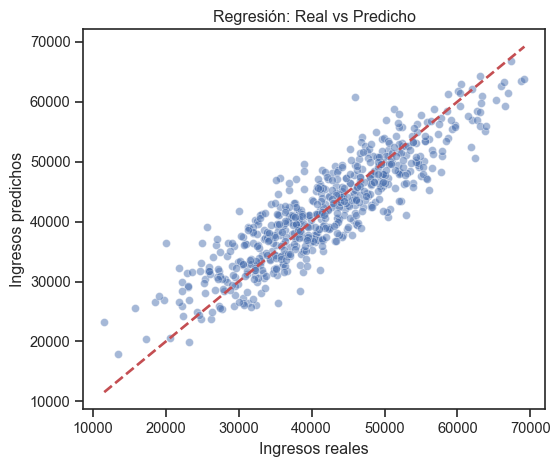

In [4]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x=yr_test, y=pred_r, alpha=0.5)
lims = [min(yr_test.min(), pred_r.min()), max(yr_test.max(), pred_r.max())]
plt.plot(lims, lims, 'r--', linewidth=2)
plt.title('Regresión: Real vs Predicho')
plt.xlabel('Ingresos reales')
plt.ylabel('Ingresos predichos')
plt.tight_layout()
plt.show()

## 2. Caso de Clasificación: Conversión de Leads

### ¿Qué es?
Ahora el objetivo cambia: queremos clasificar si un lead **convertirá** (1) o **no convertirá** (0).

Compararemos dos modelos clásicos:
- Regresión Logística: simple, estable e interpretable
- Árbol de Decisión: flexible y fácil de explicar por reglas

### ¿Para qué sirve?
La clasificación permite priorizar acciones comerciales.

Ejemplo práctico:
- Leads con mayor probabilidad de conversión pueden ir a un equipo senior
- Leads con menor probabilidad pueden entrar a un flujo automatizado

Esto mejora productividad y aumenta conversión sin aumentar proporcionalmente el costo.

### ¿Cómo se usa?
1. Entrenar ambos modelos con el mismo dataset
2. Medir accuracy, precision, recall y F1
3. Elegir según objetivo de negocio (no siempre gana el mayor accuracy)

In [5]:
n_clf = 3500

df_clf = pd.DataFrame({
    'edad': np.random.randint(21, 66, n_clf),
    'ingreso_estimado': np.random.normal(1400, 450, n_clf).clip(300, 5000),
    'interacciones_7d': np.random.poisson(3.2, n_clf),
    'fuente_lead': np.random.choice(['organico', 'paid', 'referido', 'email'], n_clf, p=[0.30, 0.35, 0.20, 0.15]),
    'tipo_empresa': np.random.choice(['micro', 'pyme', 'corporativo'], n_clf, p=[0.50, 0.35, 0.15])
})

score = (
    -2.6
    + 0.0022 * df_clf['ingreso_estimado']
    + 0.28 * df_clf['interacciones_7d']
    + 0.45 * (df_clf['fuente_lead'] == 'referido').astype(int)
    + 0.30 * (df_clf['tipo_empresa'] == 'corporativo').astype(int)
    + np.random.normal(0, 0.6, n_clf)
)

proba_conv = 1 / (1 + np.exp(-score))
df_clf['convertido'] = np.random.binomial(1, proba_conv)

print('Tasa de conversión: {:.2%}'.format(df_clf['convertido'].mean()))
df_clf.head()

Tasa de conversión: 76.23%


,edad,ingreso_estimado,interacciones_7d,fuente_lead,tipo_empresa,convertido
0,52,1011.413272,2,referido,pyme,0
1,55,1721.412881,3,paid,micro,1
2,52,2262.383966,6,organico,pyme,1
3,54,1543.026934,4,email,micro,1
4,57,1865.141230,3,organico,micro,0


In [6]:
# ------------------------------------------------------
# Entrenamos dos modelos de clasificacion comparables
# ------------------------------------------------------
Xc = df_clf.drop(columns=['convertido'])
yc = df_clf['convertido']

# Stratify mantiene la proporcion de clases en train/test.
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.25, random_state=42, stratify=yc
)

num_c = Xc.select_dtypes(include=['number']).columns.tolist()
cat_c = Xc.select_dtypes(exclude=['number']).columns.tolist()

prep_c = ColumnTransformer([
    ('num', StandardScaler(), num_c),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_c)
])

# Modelo 1: lineal e interpretable
modelo_log = Pipeline([('prep', prep_c), ('clf', LogisticRegression(max_iter=1200))])

# Modelo 2: no lineal, basado en reglas
modelo_tree = Pipeline([('prep', prep_c), ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))])

modelo_log.fit(Xc_train, yc_train)
modelo_tree.fit(Xc_train, yc_train)

pred_log = modelo_log.predict(Xc_test)
pred_tree = modelo_tree.predict(Xc_test)

# Funcion util para resumir metricas de clasificacion.
def resumen_clf(y_true, y_pred, nombre):
    return {
        'modelo': nombre,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0)
    }

comp = pd.DataFrame([
    resumen_clf(yc_test, pred_log, 'Regresión Logística'),
    resumen_clf(yc_test, pred_tree, 'Árbol de Decisión')
]).set_index('modelo').round(3)

comp

,accuracy,precision,recall,f1
modelo,,,,
Regresión Logística,0.760,0.793,0.928,0.855
Árbol de Decisión,0.725,0.803,0.847,0.824


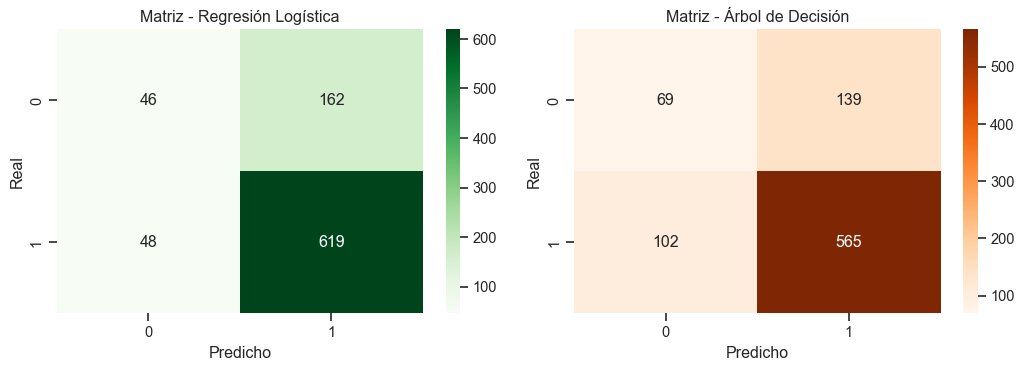

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm_log = confusion_matrix(yc_test, pred_log)
cm_tree = confusion_matrix(yc_test, pred_tree)

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title('Matriz - Regresión Logística')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Matriz - Árbol de Decisión')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

## 3. Interpretación Básica de Modelos

### ¿Qué es?
Interpretar un modelo es identificar **qué variables explican más** la predicción.

No basta con obtener buena métrica: también debemos entender por qué el modelo decide.

### ¿Para qué sirve?
Porque en analítica aplicada la confianza del stakeholder es clave.

Si puedes explicar factores relevantes, el resultado es:
- Más credibilidad del análisis
- Mayor adopción por parte del negocio
- Mejor capacidad para definir acciones concretas

### ¿Cómo se usa?
En este ejemplo revisamos importancias del árbol para detectar los drivers principales y discutir implicaciones operativas.

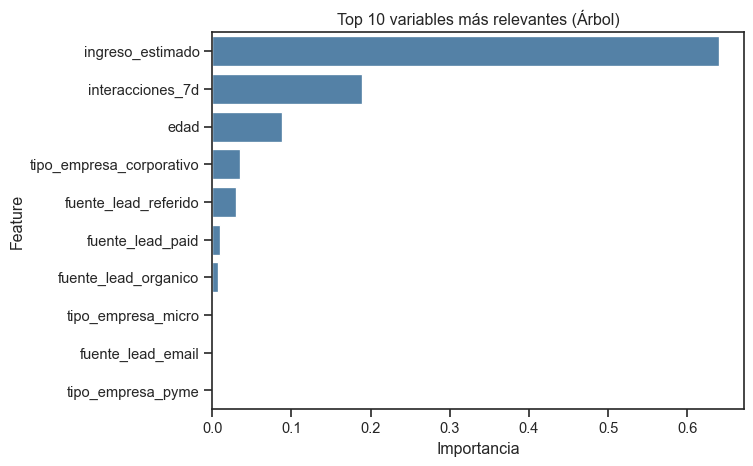

,feature,importancia
1,ingreso_estimado,0.639279
2,interacciones_7d,0.189475
0,edad,0.087749
7,tipo_empresa_corporativo,0.034592
6,fuente_lead_referido,0.030562
5,fuente_lead_paid,0.010401
4,fuente_lead_organico,0.007397
8,tipo_empresa_micro,0.000546
3,fuente_lead_email,0.000000
9,tipo_empresa_pyme,0.000000


In [8]:
ohe = modelo_tree.named_steps['prep'].named_transformers_['cat']
nombres_cat = ohe.get_feature_names_out(cat_c).tolist()
nombres_features = num_c + nombres_cat

importancias = modelo_tree.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({'feature': nombres_features, 'importancia': importancias})
imp_df = imp_df.sort_values('importancia', ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=imp_df, x='importancia', y='feature', color='steelblue')
plt.title('Top 10 variables más relevantes (Árbol)')
plt.xlabel('Importancia')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

imp_df

## 4. Ejercicio Práctico Integrador

### ¿Qué es?
Un ejercicio para entrenar criterio analítico, no solo ejecución técnica.

### ¿Para qué sirve?
Te obliga a tomar decisiones como lo haría un analista en un entorno real:
- comparar alternativas
- analizar trade-offs
- justificar una recomendación

### Instrucciones
1. Cambia max_depth del árbol a 3, 7 y 10
2. Registra accuracy, recall y F1
3. Elige la mejor configuración para un equipo comercial
4. Justifica tu elección en 4 líneas considerando impacto de negocio

Sugerencia: si el objetivo es no perder oportunidades, recall suele ser crítico.

In [9]:
resultados_depth = []
for d in [3, 7, 10]:
    m = Pipeline([
        ('prep', prep_c),
        ('clf', DecisionTreeClassifier(max_depth=d, random_state=42))
    ])
    m.fit(Xc_train, yc_train)
    p = m.predict(Xc_test)
    resultados_depth.append({
        'max_depth': d,
        'accuracy': accuracy_score(yc_test, p),
        'recall': recall_score(yc_test, p, zero_division=0),
        'f1': f1_score(yc_test, p, zero_division=0)
    })

pd.DataFrame(resultados_depth).round(3)

,max_depth,accuracy,recall,f1
0,3,0.767,0.985,0.866
1,7,0.731,0.864,0.831
2,10,0.710,0.828,0.813


## Glosario de referencia

| Concepto | Qué es |
|---|---|
| Regresión | Predecir un valor **numérico** continuo |
| Clasificación | Predecir una **categoría** |
| Regresión lineal | Ajusta una recta / plano a los datos |
| Regresión logística | Clasificador lineal (da probabilidades) |
| Árbol de decisión | Modelo de reglas *si / entonces* |
| MAE / RMSE | Error medio / penaliza más los errores grandes |
| R² | % de la variación que el modelo explica |
| `max_depth` | Profundidad del árbol (controla el sobreajuste) |
| Importancia de features | Cuánto pesa cada variable en la predicción |

## Cierre

En este notebook practicaste:
- Regresión lineal para estimar una variable continua
- Clasificación binaria con dos enfoques complementarios
- Comparación de métricas para elegir modelo con criterio
- Lectura de matriz de confusión e interpretación de errores
- Identificación de variables relevantes para explicar decisiones

Idea clave: un buen analista no solo reporta métricas, también traduce resultados en decisiones accionables.

Siguiente paso recomendado: notebook 16 para profundizar en umbrales, costos de error y recomendación ejecutiva.

---
<p style="color:#898781;font-size:12px">Data Analytics Básico · Módulo 15 — Análisis avanzado</p>